<a href="https://colab.research.google.com/github/fergonzalvo/ISSD_PH/blob/main/%E2%9A%A1Gonzalvo_Fernando_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Fernando Gonzalvo]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [32]:
import requests
from bs4 import BeautifulSoup

sitio = "https://www.marxists.org/espanol/king/1963/agosto28.htm"
respuesta = requests.get(sitio)

respuesta.encoding = respuesta.apparent_encoding # codificación utf-8 o latin1 para evitar problemas de caracteres en español
soup = BeautifulSoup(respuesta.text, "html.parser")

parrafos = soup.find_all("p")#busco parrafos

discurso = [p.get_text(strip=True) for p in parrafos if p.get_text(strip=True)]#extraemos el texto de cada párrafo omitiendo líneas vacías
texto_completo = "\n\n".join(discurso)#unimos

print(f"discurso:\n{texto_completo[:1000]}")  # muestra los primeros 1000 caracteres

discurso:
Pronunciado:El 28 de agosto de 1963 delante del
monumento a Abraham Lincoln en Washington, DC, durante una histórica manifestación de más
de 200,000 en pro de los derechos civiles para los negros en los EE.UU.Versión al castellano:No consta.Versión digital:Wikisource
en Español, 2006.Esta edición:Marxists Internet Archive, septiembre
de  2006.Derechos:El contenido está disponible bajo los términos de
laGNU Free Documentation License.

Estoy orgulloso de reunirme con ustedes hoy, en la que será ante la historia la mayor manifestación por la libertad en la historia de nuestro país.Hace cien años, un gran estadounidense, cuya simbólica sombra nos cobija hoy, firmó la Proclama de la emancipación. Este trascendental decreto significó como un gran rayo de luz y de esperanza para millones de esclavos negros, chamuscados en las llamas de una marchita injusticia. Llegó como un precioso amanecer al final de una larga noche de cautiverio. Pero, cien años después, el negro aún no es libr

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [33]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('punkt') #entorno


palabras = word_tokenize(texto_completo.lower())#minusculas con .lower

stopwords_es = set(stopwords.words('spanish'))# la lista oficial de stopwords en español


stopwords_presentes = set([word for word in palabras if word in stopwords_es])#busco las stopwords_es en palabras

print("total sw")
print(len(stopwords_presentes))

print("algunas sw")
print(list(stopwords_presentes)[:20])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


total sw
91
algunas sw
['de', 'porque', 'como', 'hasta', 'habrá', 'pero', 'todo', 'al', 'yo', 'te', 'míos', 'entre', 'más', 'algo', 'nuestras', 'la', 'estamos', 'nuestra', 'nuestros', 'muchos']


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

### 2.3 Usando el texto que conseguiste en el punto 1).


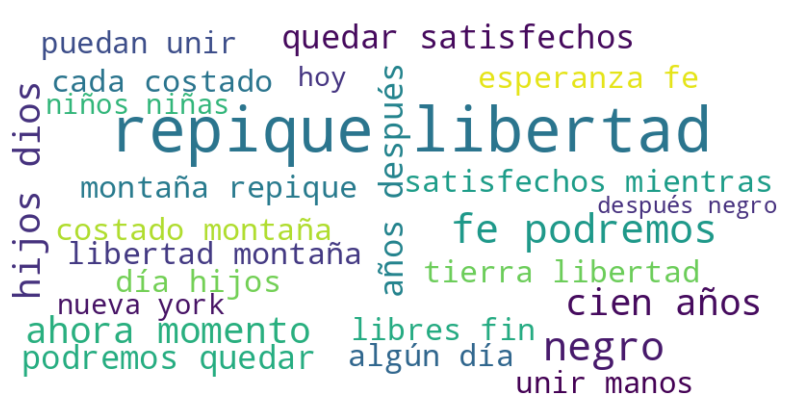

In [34]:
import re  # Se importa la librería para expresiones regulares
from wordcloud import WordCloud  # Se importa la clase WordCloud para generar la imagen
import matplotlib.pyplot as plt  # Se importa pyplot para visualizar la nube de palabras

texto_solo_letras = re.sub(r'[^a-záéíóúñ\s]', '', texto_completo.lower()) # Se dejan únicamente letras en español y espacios

palabras = texto_solo_letras.split() # Se divide el texto en una lista de palabras individuales

palabras_limpias = [word for word in palabras if word not in stopwords_es] # Se conservan solo las palabras que no son stop-words

texto_final = " ".join(palabras_limpias) # Se unen las palabras filtradas en un solo string de texto continuo

nube = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=25
    ).generate(texto_final) # Se crea el objeto WordCloud con el texto procesado y se configura la cantidad de palabras con max_word


plt.figure(figsize=(10, 5)) # Se define el tamaño de la figura para la imagen
plt.imshow(nube, interpolation='bilinear') # Se renderiza la imagen de la nube de palabras
plt.axis("off") # Se ocultan los ejes para mejorar la presentación visual
plt.show() # Se despliega la imagen final en el entorno de ejecución


#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [35]:
import nltk # Se importa la librería NLTK para procesamiento de lenguaje natural
from nltk.tokenize import sent_tokenize # Se importa el tokenizador de oraciones
from sklearn.feature_extraction.text import CountVectorizer # Se importa CountVectorizer para construir la matriz documento-vocabulario
import pandas as pd # Se importa pandas para estructurar la matriz en formato DataFrame


nltk.download('punkt') # Se descarga el paquete punkt necesario para segmentar el texto en oraciones
nltk.download('punkt_tab') # Se descarga el paquete auxiliar punkt_tab para compatibilidad

oraciones = sent_tokenize(texto_completo) # Se divide el texto completo en una lista de oraciones individuales
vectorizador = CountVectorizer(stop_words=list(stopwords_es)) # Se instancia el vectorizador configurando las stopwords en español a omitir
matriz_dtm = vectorizador.fit_transform(oraciones) # Se transforma la lista de oraciones en una matriz dispersa documento-vocabulario (frecuencias)

vocabulario = vectorizador.get_feature_names_out() # Se obtiene la lista con las palabras únicas que conforman el vocabulario
df_matriz = pd.DataFrame(matriz_dtm.toarray(), columns=vocabulario) # Se convierte la matriz a un DataFrame de pandas con las palabras como columnas

longitud_vocabulario = len(vocabulario) # Se calcula la cantidad total de palabras únicas presentes en el vocabulario

print("=== MUESTRA DE LA MATRIZ DOCUMENTO-VOCABULARIO ===") # Se imprime el encabezado para la matriz
print(df_matriz.head()) # Se muestran las primeras filas del DataFrame de la matriz



=== MUESTRA DE LA MATRIZ DOCUMENTO-VOCABULARIO ===
   000  1963  200  2006  28  abraham  acelerar  actos  adelante  afirmamos  \
0    1     1    1     2   1        1         0      0         0          0   
1    0     0    0     0   0        0         0      0         0          0   
2    0     0    0     0   0        0         0      0         0          0   
3    0     0    0     0   0        0         0      0         0          0   
4    0     0    0     0   0        0         0      0         0          0   

   ...  vigorizante  violencia  vive  vivirá  vivirán  volver  votar  \
0  ...            0          0     0       0        0       0      0   
1  ...            0          0     0       0        0       0      0   
2  ...            0          0     0       0        0       0      0   
3  ...            0          0     0       0        0       0      0   
4  ...            0          0     1       0        0       0      0   

   washington  wikisource  york  
0           1

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



#### 2.3.2 Determina la longitud de tu vocabulario.

In [36]:
print("longitud vocabulario:")
print(f"total de {longitud_vocabulario} palabras únicas.") # Se despliega el total de términos únicos extraídos

longitud vocabulario:
total de 517 palabras únicas.



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer  # Se importa TfidfVectorizer para calcular el peso TF-IDF
import pandas as pd  # Se importa pandas para convertir la matriz en un DataFrame estructurado


vectorizador_tfidf = TfidfVectorizer(stop_words=list(stopwords_es))  # Se instancia el vectorizador TF-IDF configurando la lista de stopwords en español
matriz_tfidf = vectorizador_tfidf.fit_transform(oraciones)  # Se calcula la matriz TF-IDF transformando la lista de oraciones

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()  # Se extraen las palabras únicas reconocidas por el modelo TF-IDF
df_tfidf = pd.DataFrame(matriz_tfidf.toarray(), columns=vocabulario_tfidf)  # Se convierte la matriz TF-IDF a un DataFrame donde cada columna representa un término

print("=== MATRIZ TF-IDF (PRIMERAS FILAS) ===")  # Se imprime el encabezado descriptivo
print(df_tfidf.head())  # Se muestran las primeras filas con los pesos ponderados por oración

print("\n=== PALABRAS CON MAYOR PESO TF-IDF PROMEDIO ===")  # Se imprime el encabezado para el top de palabras más relevantes
pesos_promedio = df_tfidf.mean(axis=0).sort_values(ascending=False)  # Se calcula la puntuación promedio de cada palabra a lo largo de todas las oraciones
print(pesos_promedio.head(10))  # Se muestran las 10 palabras con mayor relevancia según el cálculo de TF-IDF

=== MATRIZ TF-IDF (PRIMERAS FILAS) ===
        000      1963       200      2006        28   abraham  acelerar  \
0  0.148407  0.125277  0.148407  0.296815  0.148407  0.148407       0.0   
1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000       0.0   
2  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000       0.0   
3  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000       0.0   
4  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000       0.0   

   actos  adelante  afirmamos  ...  vigorizante  violencia      vive  vivirá  \
0    0.0       0.0        0.0  ...          0.0        0.0  0.000000     0.0   
1    0.0       0.0        0.0  ...          0.0        0.0  0.000000     0.0   
2    0.0       0.0        0.0  ...          0.0        0.0  0.000000     0.0   
3    0.0       0.0        0.0  ...          0.0        0.0  0.000000     0.0   
4    0.0       0.0        0.0  ...          0.0        0.0  0.110351     0.0   

   vivirán  volver  votar  wa

Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [38]:
# instalar wordcloud
!pip install wordcloud


In [39]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [40]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

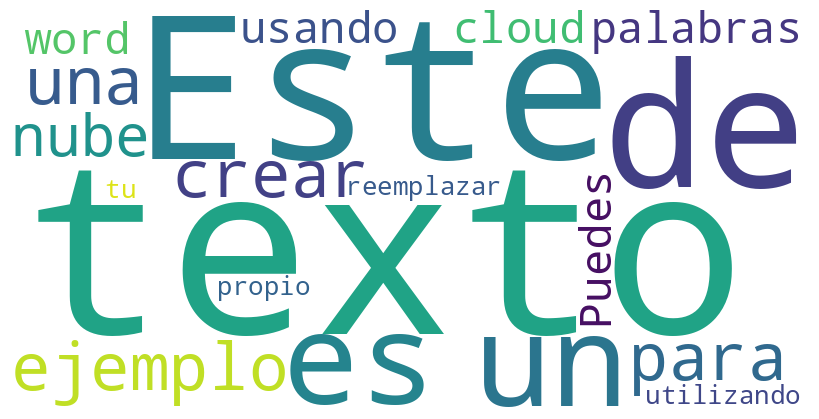

In [41]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



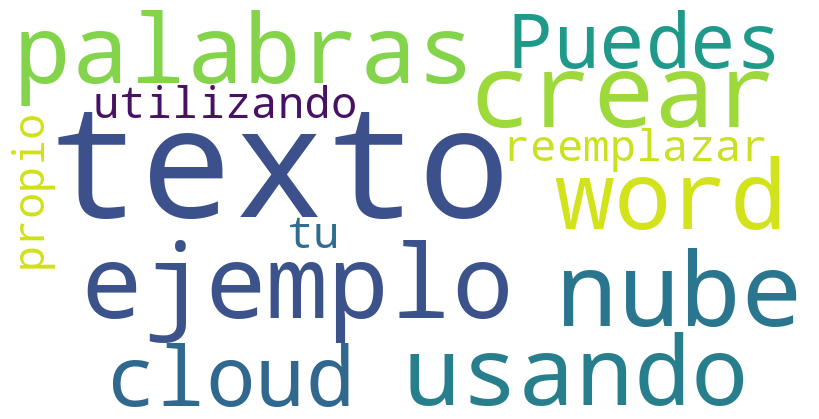

In [42]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
